<a href="https://colab.research.google.com/github/Dounia-Nassar/Customer-Segmentation-Credit-Card/blob/main/KMeans_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KMeans Clustering — Customer Segmentation
**Author:** Dounia Nassar   
**Goal:** Segment customers to help a credit card company tailor its marketing strategy

---
## Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


---
## Data Loading & Preprocessing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/AXSOSACADEMY/03-IntermediateML/Week18/Data/cust_seg.csv"
df = pd.read_csv(path)
df.head()

,Unnamed: 0,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,0,1,41,2,6,19,0.124,1.073,0.0,6.3
1,1,2,47,1,26,100,4.582,8.218,0.0,12.8
2,2,3,33,2,10,57,6.111,5.802,1.0,20.9
3,3,4,29,2,4,19,0.681,0.516,0.0,6.3
4,4,5,47,1,31,253,9.308,8.908,0.0,7.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       850 non-null    int64  
 1   Customer Id      850 non-null    int64  
 2   Age              850 non-null    int64  
 3   Edu              850 non-null    int64  
 4   Years Employed   850 non-null    int64  
 5   Income           850 non-null    int64  
 6   Card Debt        850 non-null    float64
 7   Other Debt       850 non-null    float64
 8   Defaulted        700 non-null    float64
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(6)
memory usage: 66.5 KB


In [ ]:
df = df.drop(columns=["Unnamed: 0", "Customer Id"])
print("Shape:", df.shape)

Shape: (850, 8)


In [ ]:
null = df.isnull().sum()
print("Null values:")
print(null)

Null values:
Age                  0
Edu                  0
Years Employed       0
Income               0
Card Debt            0
Other Debt           0
Defaulted          150
DebtIncomeRatio      0
dtype: int64


In [ ]:
df['Defaulted']= df['Defaulted'].fillna(df['Defaulted'].median())
print(df.isnull().sum())

Age                0
Edu                0
Years Employed     0
Income             0
Card Debt          0
Other Debt         0
Defaulted          0
DebtIncomeRatio    0
dtype: int64


In [ ]:
df.describe().round(2)

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
count,850.00,850.00,850.00,850.00,850.00,850.00,850.00,850.00
mean,35.03,1.71,8.57,46.68,1.58,3.08,0.22,10.17
std,8.04,0.93,6.78,38.54,2.13,3.40,0.41,6.72
min,20.00,1.00,0.00,13.00,0.01,0.05,0.00,0.10
25%,29.00,1.00,3.00,24.00,0.38,1.05,0.00,5.10
50%,34.00,1.00,7.00,35.00,0.88,2.00,0.00,8.70
75%,41.00,2.00,13.00,55.75,1.90,3.90,0.00,13.80
max,56.00,5.00,33.00,446.00,20.56,35.20,1.00,41.30


In [ ]:
# Scale all features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
X_scaled_df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,0.742915,0.312122,-0.378790,-0.718459,-0.683811,-0.590489,-0.523797,-0.576525
1,1.489490,-0.766349,2.573721,1.384325,1.414474,1.512962,-0.523797,0.391387
2,-0.252518,0.312122,0.211712,0.268032,2.134141,0.801704,1.909138,1.597554
3,-0.750235,0.312122,-0.674041,-0.718459,-0.421643,-0.754467,-0.523797,-0.576525
4,1.489490,-0.766349,3.311849,5.356249,3.638900,1.716094,-0.523797,-0.442507


---
## Part 1: Finding the Optimal Number of Clusters (K)

We use two complementary methods:
- **Elbow Plot** — looks for the elbow where adding more clusters stops reducing inertia significantly
- **Silhouette Score** — measures how well-separated the clusters are (higher = better)

/tmp/ipykernel_1517/1297489747.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(); axes[0].grid(alpha=0.3)
/tmp/ipykernel_1517/1297489747.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(); axes[1].grid(alpha=0.3)


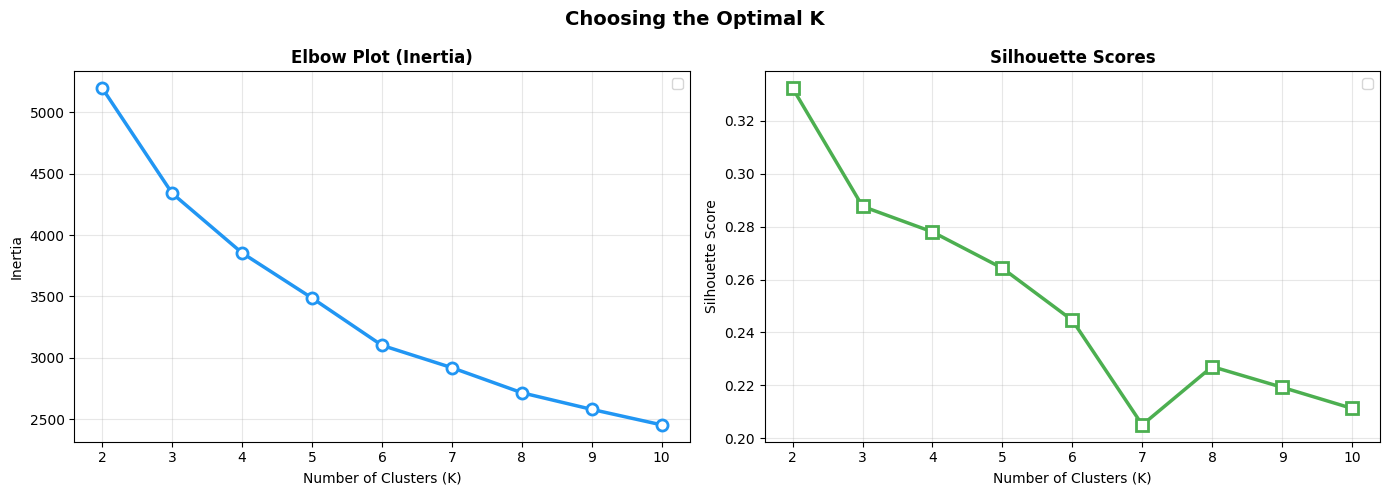

In [ ]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Choosing the Optimal K", fontsize=14, fontweight="bold")

# Elbow
axes[0].plot(k_range, inertias, "o-", color="#2196F3", linewidth=2.5, markersize=8,
             markerfacecolor="white", markeredgewidth=2)
axes[0].set_title("Elbow Plot (Inertia)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (K)"); axes[0].set_ylabel("Inertia")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(k_range, silhouette_scores, "s-", color="#4CAF50", linewidth=2.5, markersize=8,
             markerfacecolor="white", markeredgewidth=2)
axes[1].set_title("Silhouette Scores", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (K)"); axes[1].set_ylabel("Silhouette Score")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Why K = 3?

- The **Elbow Plot** shows inertia drops sharply from K=2 to K=3, then flattens — the classic elbow is at K=3.
- The **Silhouette Score** at K=2 is highest numerically, but K=2 produces only two very broad groups with little business value. K=3 gives a more meaningful and interpretable segmentation while still having a reasonable silhouette score.
- K=3 creates **three distinct, actionable customer profiles** — ideal for credit card marketing strategy.

---
## Fit Final Model: K = 3

In [ ]:
K = 3
km_final = KMeans(n_clusters=K, random_state=42, n_init='auto')
km_final.fit(X_scaled)

df["Cluster"] = km_final.labels_
df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,Cluster
0,41,2,6,19,0.124,1.073,0.0,6.3,0
1,47,1,26,100,4.582,8.218,0.0,12.8,2
2,33,2,10,57,6.111,5.802,1.0,20.9,1
3,29,2,4,19,0.681,0.516,0.0,6.3,0
4,47,1,31,253,9.308,8.908,0.0,7.2,2


---
## Part 2: Analyzing the Clusters

In [ ]:
cluster_group = df.groupby("Cluster", as_index=False).mean().round(2)
cluster_group

,Cluster,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,0,33.83,1.60,7.65,36.18,0.86,1.82,0.00,7.99
1,1,31.89,1.86,3.96,31.79,1.58,2.84,0.99,13.99
2,2,43.09,1.93,17.22,102.72,4.23,8.02,0.13,13.89


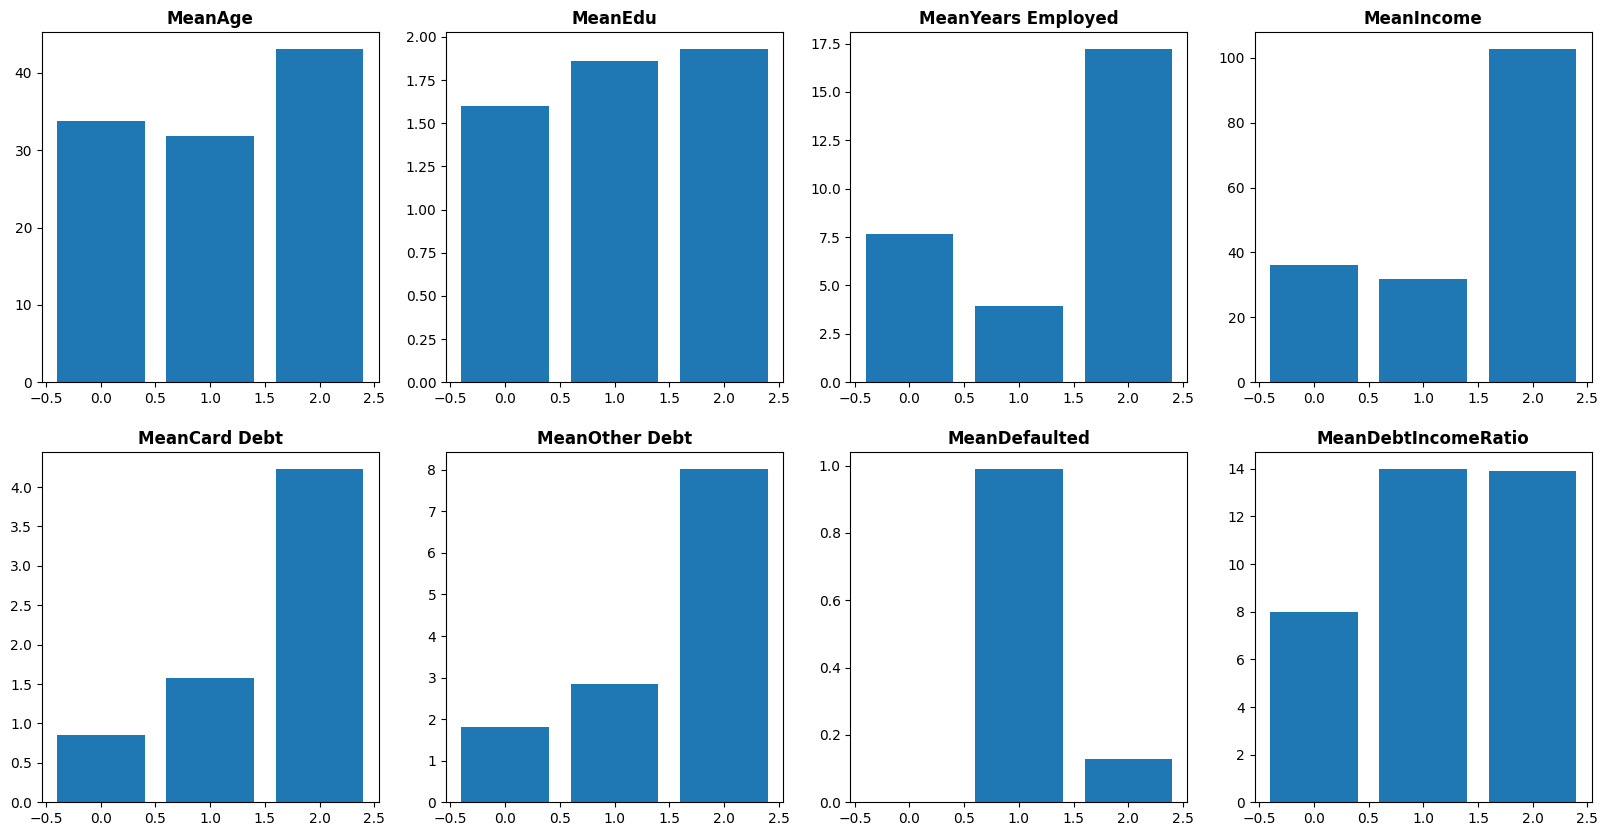

In [ ]:
fig, axes = plt.subplots(2,4,figsize=(20, 10))
axes = axes.ravel()
for i, col in enumerate(cluster_group.columns[1:]):
    axes[i].bar(cluster_group['Cluster'], cluster_group[col])
    axes[i].set_title(f'Mean{col}', fontsize=12, fontweight="bold")

--# Cluster Descriptions

Based on the visualizations above, here is a description of each cluster — going beyond the numbers to describe the **people** behind each group.

---

###Cluster 0 — "Young & Cautious" (n=304)

**Who they are:**  
This is the **largest segment** of younger to middle-aged customers (avg age 33.83) with moderate employment history (avg 7.65 years) and mid-range income (avg 36.18K). They are characterized by **very low debt** (Card Debt avg 0.86K, Other Debt avg 1.82K) and an impressive **0% default rate**. These customers are financially responsible and conservative with credit.

**Key insight:**  
This group represents untapped potential. They are reliable, but currently underusing credit products. They have room to responsibly grow their credit usage — making them ideal candidates for upgrades and new products.

---

###Cluster 1 — "Young & High-Risk" (n=166)

**Who they are:**  
These are the **youngest customers** (avg age 31.89) with the least employment experience (avg 3.96 years) and the lowest income (avg 31.79K). Their debt-to-income ratio (avg 13.99) is the highest, and a staggering **99% of them have defaulted**. This is the most financially vulnerable segment, likely early-career individuals who took on more credit than their income could support.

**Key insight:**  
This group is not necessarily irresponsible — they are simply young, early in their careers, and likely overwhelmed by their debt load relative to income. They need structured support, not outright rejection.

---

###Cluster 2 — "Established & Stable" (n=380)

**Who they are:**  
This group consists of the **oldest customers** (avg age 43.09) with the most extensive employment history (avg 17.22 years) and by far the highest income (avg 102.72K). They carry the highest debt levels (Card Debt avg 4.23K, Other Debt avg 8.02K), but this is indicative of their purchasing power and financial capacity rather than distress. Their default rate is low (13%), suggesting they manage their finances well.

**Key insight:**  
Despite having the highest debt levels, this group manages it well due to their high income. Their high income allows them to absorb a higher debt-to-income ratio. These customers likely hold multiple credit products and are high spenders.

#Part 3 — 2 Recommendations:

1. Differentiate card products by cluster (premium for Cluster 0, upgrade campaigns for Cluster 2)

2. A recovery/support program for Cluster 1 instead of rejecting them